In [1]:
import torch
import numpy as np
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T
from torch_geometric.nn import to_hetero, GATConv, Linear
import pandas as pd
import gudhi
import networkx as nx
from scipy.spatial.distance import pdist, squareform
import scanpy as sc
import numpy as np
import ast
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

/home/nkise/Documents/Anya/single_cell_project/torchsparse-env/.venv/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/nkise/Documents/Anya/single_cell_project/torchsparse-env/.venv/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/nkise/Documents/Anya/single_cell_project/torchsparse-env/.venv/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/nkise/Documents/Anya/single_cell_project/torchsparse-env/.venv/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warn

## Extract data

* Attention weights

In [ ]:
adata = sc.read_h5ad("/NicheCompass/artifacts/single_sample/26032025_173236/model/xenium_adult_colon_hs_NicheCompass_AM_26032025_173236_raw.h5ad")

In [ ]:
nichecompass_summary = pd.read_csv("/NicheCompass/artifacts/single_sample/26032025_173236/figures/log_bayes_factor_2.3_all_enriched_gps_summary.csv")

In [4]:
nichecompass_summary

,Unnamed: 0,gp_name,n_source_genes,n_non_zero_source_genes,n_target_genes,n_non_zero_target_genes,gp_source_genes,gp_target_genes,gp_source_genes_importances,gp_target_genes_importances
0,10,ANPEP_ligand_receptor_target_gene_GP,1,1,28,28,['ANPEP'],"['LEF1', 'CD36', 'MMP1', 'TK1', 'CXCL2', 'CCL2...",[0.4576],"[0.1063, 0.0504, 0.0431, 0.0349, 0.0331, 0.031..."
1,45,ANXA1_combined_GP,1,1,28,28,['ANXA1'],"['ADRA2A', 'F3', 'CCL20', 'MMP1', 'ID2', 'SOCS...",[0.4374],"[0.1041, 0.0524, 0.0352, 0.0321, 0.0318, 0.027..."
2,46,APOB_combined_GP,1,1,29,29,['APOB'],"['STMN1', 'APOB', 'LEF1', 'CTNNB1', 'SERPINE1'...",[0.0483],"[0.0957, 0.0808, 0.0807, 0.0768, 0.0735, 0.064..."
3,48,AREG_combined_GP,1,1,12,12,['AREG'],"['CLCA4', 'NXPE4', 'PLN', 'CXCL13', 'PIGR', 'C...",[0.0517],"[0.1908, 0.1765, 0.1674, 0.1337, 0.1164, 0.072..."
4,49,AZGP1_combined_GP,1,1,23,23,['AZGP1'],"['ACTA2', 'SOCS3', 'CXCL1', 'IL1B', 'TNFAIP3',...",[0.0577],"[0.233, 0.1621, 0.0893, 0.0642, 0.0633, 0.0566..."
...,...,...,...,...,...,...,...,...,...,...
98,105,TTR_combined_GP,1,1,18,18,['TTR'],"['SOCS3', 'IL1B', 'MMP1', 'CXCR4', 'SERPINE1',...",[0.0011],"[0.3074, 0.0984, 0.095, 0.0917, 0.078, 0.0616,..."
99,106,UCN3_combined_GP,1,1,26,26,['UCN3'],"['VWF', 'TNFAIP3', 'CDK6', 'MMP3', 'ID2', 'CTS...",[0.0103],"[0.1831, 0.1318, 0.1099, 0.0836, 0.0704, 0.068..."
100,108,VWF_combined_GP,1,1,27,27,['VWF'],"['CD36', 'TNFAIP3', 'CDK6', 'RUNX1', 'ID2', 'C...",[0.169],"[0.1285, 0.1202, 0.0754, 0.0586, 0.0573, 0.051..."
101,109,WNT5B_combined_GP,1,1,14,14,['WNT5B'],"['ADAM28', 'CMBL', 'CD79B', 'CD5', 'FZD7', 'CK...",[0.0173],"[0.1823, 0.1555, 0.132, 0.1193, 0.0984, 0.0755..."


In [5]:
df = adata.uns['nichecompass_differential_gp_test_results']

In [6]:
df_category_14 = df[df['category'] == '2']
df_category_14.head()

,category,gene_program,p_h0,p_h1,log_bayes_factor
26,2,Add-on_18_GP,0.009501,0.990499,-4.646857
154,2,FCER2_ligand_receptor_target_gene_GP,0.076153,0.923847,-2.495797
157,2,Add-on_26_GP,0.922621,0.077379,2.478499
168,2,AZGP1_combined_GP,0.080838,0.919162,-2.431014
182,2,LEFTY1_combined_GP,0.912248,0.087752,2.341398


In [7]:
Add_on_18_GP = nichecompass_summary[nichecompass_summary['gp_name'] == 'Add-on_18_GP']
Add_on_18_GP.head()

,Unnamed: 0,gp_name,n_source_genes,n_non_zero_source_genes,n_target_genes,n_non_zero_target_genes,gp_source_genes,gp_target_genes,gp_source_genes_importances,gp_target_genes_importances
6,129,Add-on_18_GP,315,151,188,51,"['SMOC2', 'LGR5', 'DMBT1', 'ASCL2', 'CA7', 'EP...","['SMOC2', 'ASCL2', 'CA7', 'EPHB3', 'L1TD1', 'L...","[0.0395, 0.0377, 0.037, 0.031, 0.0295, 0.0246,...","[0.0307, 0.0246, 0.0238, 0.0203, 0.0154, 0.014..."


In [8]:
source_genes_13 = Add_on_18_GP['gp_source_genes'].values[0]
source_weights_13 = Add_on_18_GP['gp_source_genes_importances'].values[0]

target_genes_13 = Add_on_18_GP['gp_target_genes'].values[0]
target_weights_13 = Add_on_18_GP['gp_target_genes_importances'].values[0]

In [9]:
def convert_weights_string(weights_str):
    # Make sure the string is properly formatted with brackets
    if not weights_str.startswith('['):
        weights_str = '[' + weights_str
    if not weights_str.endswith(']'):
        weights_str = weights_str + ']'
    
    # Convert to list of floats
    try:
        weights_list = ast.literal_eval(weights_str)
        return weights_list
    except (SyntaxError, ValueError) as e:
        print(f"Error converting weights: {e}")
        return None

In [10]:
source_weights_13 = convert_weights_string(source_weights_13)

In [11]:
source_genes_13 = ast.literal_eval(source_genes_13)

In [12]:
type(source_weights_13)

list

In [13]:
attention_weights = torch.tensor(source_weights_13, dtype=torch.float)
gene_names = source_genes_13

## PPI

+ Gene to protein

In [14]:
#from pybiomart import Dataset

In [15]:
#dataset = Dataset(name="hsampiens", host = "http://www.ensembl.org")

In [16]:
#annot = sc.queries.biomart_annotations(
#        "hsapiens",
#        ["ensembl_gene_id", "external_gene_name", "ensembl_peptide_id"],
#    ).set_index("external_gene_name")

In [ ]:
#annot.to_csv("Topology/ensembl_protein_to_gene.csv")

+ STRING input

In [ ]:
string = pd.read_csv("/topology/9606.protein.links.full.v12.0.txt", sep= " ")

In [19]:
string["protein1"] = string["protein1"].str.replace('9606.', '', regex=True)
string["protein2"] = string["protein2"].str.replace('9606.', '', regex=True)

In [20]:
string

,protein1,protein2,neighborhood,neighborhood_transferred,fusion,cooccurence,homology,coexpression,coexpression_transferred,experiments,experiments_transferred,database,database_transferred,textmining,textmining_transferred,combined_score
0,ENSP00000000233,ENSP00000356607,0,0,0,0,0,0,45,0,134,0,0,0,81,173
1,ENSP00000000233,ENSP00000427567,0,0,0,0,0,0,0,0,128,0,0,0,70,154
2,ENSP00000000233,ENSP00000253413,0,0,0,0,0,49,111,0,49,0,0,0,69,151
3,ENSP00000000233,ENSP00000493357,0,0,0,0,0,56,0,0,53,0,0,433,81,471
4,ENSP00000000233,ENSP00000324127,0,0,0,0,0,0,0,0,46,0,0,153,91,201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13715399,ENSP00000501317,ENSP00000475489,0,0,0,0,0,60,0,0,99,0,0,126,0,195
13715400,ENSP00000501317,ENSP00000370447,0,0,0,0,0,0,55,0,111,0,0,0,79,158
13715401,ENSP00000501317,ENSP00000312272,0,0,0,0,0,0,0,0,0,0,0,187,88,226
13715402,ENSP00000501317,ENSP00000402092,0,0,0,0,0,0,0,0,67,0,0,146,0,169


In [ ]:
p_to_g = pd.read_csv("/topology/ensembl_protein_to_gene.csv")

In [22]:
p_to_g

,external_gene_name,ensembl_gene_id,ensembl_peptide_id
0,MT-TF,ENSG00000210049,NaN
1,MT-RNR1,ENSG00000211459,NaN
2,MT-TV,ENSG00000210077,NaN
3,MT-RNR2,ENSG00000210082,NaN
4,MT-TL1,ENSG00000209082,NaN
...,...,...,...
201454,SNHG12,ENSG00000197989,NaN
201455,TAF12-DT,ENSG00000229388,NaN
201456,NaN,ENSG00000289291,NaN
201457,RNU11,ENSG00000274978,NaN


In [23]:
keep_cols = ['protein1', 'protein2', 'neighborhood', 'fusion', 'cooccurence', 
                 'homology', 'experiments', 'database']
ppi_clean = string[keep_cols].copy()

In [24]:
score_cols = ['neighborhood', 'fusion', 'cooccurence', 
                'homology', 'experiments', 'database']
ppi_clean['combined_score'] = ppi_clean[score_cols].sum(axis=1)

In [25]:
gene_to_peptide = dict(zip(p_to_g['external_gene_name'], p_to_g['ensembl_peptide_id']))

In [26]:
target_peptides = set()
for gene in gene_names:
    if gene in gene_to_peptide:
        target_peptides.add(gene_to_peptide[gene])

In [27]:
ppi_filtered = ppi_clean[
        (ppi_clean['protein1'].isin(target_peptides)) & 
        (ppi_clean['protein2'].isin(target_peptides))
    ].copy()

In [28]:
peptide_to_gene = {peptide: gene for gene, peptide in gene_to_peptide.items()}
gene_to_index = {gene: idx for idx, gene in enumerate(gene_names)}

In [29]:
ppi_filtered['gene1_idx'] = ppi_filtered['protein1'].map(
        lambda x: gene_to_index.get(peptide_to_gene.get(x, ''), -1))
ppi_filtered['gene2_idx'] = ppi_filtered['protein2'].map(
        lambda x: gene_to_index.get(peptide_to_gene.get(x, ''), -1))

In [30]:
ppi_filtered = ppi_filtered[(ppi_filtered['gene1_idx'] >= 0) & (ppi_filtered['gene2_idx'] >= 0)]

In [31]:
ppi_edge_index = torch.tensor([
        ppi_filtered['gene1_idx'].values,
        ppi_filtered['gene2_idx'].values], dtype=torch.long)

/tmp/ipykernel_10136/2366760171.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:261.)
  ppi_edge_index = torch.tensor([


In [32]:
ppi_edge_weights = torch.tensor(ppi_filtered['combined_score'].values, dtype=torch.float)

## Coexpression

In [146]:
#adata = adata[adata.obs["latent_leiden_0.4"] == "2"]

In [33]:
adata

AnnData object with n_obs × n_vars = 274037 × 425
    obs: 'Study_name', 'Donor_ID', 'Library_Preparation_Protocol', 'dataset', '_scvi_batch', '_scvi_labels', 'seed_labels', 'C_scANVI', 'SC_subsets', 'Cell_State', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_counts', 'REG4_score', 'gdT', 'Endothelial cells', 'latent_leiden_0.4', 'CD24_ligand_receptor_target_gene_GP', 'CXCL14_combined_GP', 'ANPEP_ligand_receptor_target_gene_GP', 'Add-on_76_GP', 'IL1B_combined_GP', 'CDH1_ligand_receptor_target_gene_GP', 'Add-on_37_GP', 'Add-on_28_GP', 'SLPI_ligand_receptor_target_gene_GP', 'Add-on_77_GP', 'TIMP3_ligand_receptor_target_gene_GP', 'CLU_combined_GP', 'BMP5_combined_GP', 'TNXB_ligand_receptor_target_gene_GP', 'TFF1_combined_GP', 'TNFSF13B_combined_GP', 'CCL11_combined_GP', 'Add-on_70_GP', 'gamma-Aminobutyric acid_metaboli

In [38]:
def prepare_coexpression_edges(adata, gene_names, correlation_method='pearson', threshold=0.5):
    """
    Prepare co-expression edges for your specific genes
    """
    # Filter adata to only include your genes of interest
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    #adata = adata[adata.obs["latent_leiden_0.4"] == "2"]
    gene_mask = adata.var_names.isin(gene_names)
    adata_filtered = adata[:, gene_mask]
    
    # Get the filtered gene names in the order they appear in adata
    filtered_genes = adata_filtered.var_names.tolist()
    
    # Create mapping to your gene_names indices
    gene_to_index = {gene: idx for idx, gene in enumerate(gene_names)}
    gene_indices = [gene_to_index[gene] for gene in filtered_genes if gene in gene_to_index]
    
    # Get expression matrix (cells x genes) and transpose to (genes x cells)
    expr_matrix = adata_filtered.X.T
    if hasattr(expr_matrix, 'toarray'):
        expr_matrix = expr_matrix.toarray()
    
    # Compute correlation matrix
    if correlation_method == 'pearson':
        corr_matrix = np.corrcoef(expr_matrix)
    elif correlation_method == 'spearman':
        corr_matrix, _ = spearmanr(expr_matrix, axis=1)
    
    # Remove self-correlations
    np.fill_diagonal(corr_matrix, 0)
    
    # Get indices where correlation > threshold
    i, j = np.where(np.abs(corr_matrix) > threshold)
    
    # Keep only upper triangle to avoid duplicates
    mask = i < j
    i, j = i[mask], j[mask]
    
    # Map back to original gene indices
    edge_index = torch.tensor([
        [gene_indices[i_val] for i_val in i],
        [gene_indices[j_val] for j_val in j]
    ], dtype=torch.long)
    
    # Get correlation values
    edge_weights = torch.tensor(corr_matrix[i, j], dtype=torch.float)
    
    return edge_index, edge_weights

In [39]:
coexp_edge_index, coexp_edge_weights = prepare_coexpression_edges(adata, gene_names, threshold=0.7)

In [40]:
coexp_edge_index.shape

torch.Size([2, 3])

In [41]:
coexp_edge_index.shape[1]

3

### Heterogeneous graph

In [42]:
data = HeteroData()

In [43]:
gene_features = attention_weights.unsqueeze(1)  # Shape: [num_genes, 1]
data['gene'].x = gene_features

In [44]:
data['gene'].gene_names = gene_names

In [45]:
data['gene', 'ppi', 'gene'].edge_index = ppi_edge_index
data['gene', 'ppi', 'gene'].edge_attr = ppi_edge_weights

In [46]:
data['gene', 'coexpression', 'gene'].edge_index = coexp_edge_index
data['gene', 'coexpression', 'gene'].edge_attr = coexp_edge_weights

In [47]:
print("Heterogeneous Graph:")
print(data)
print(f"\nNode types: {data.node_types}")
print(f"Edge types: {data.edge_types}")
print(f"Number of genes: {data['gene'].x.shape[0]}")
print(f"Number of PPI edges: {data['gene', 'ppi', 'gene'].edge_index.shape[1]}")
print(f"Number of co-expression edges: {data['gene', 'coexpression', 'gene'].edge_index.shape[1]}")

Heterogeneous Graph:
HeteroData(
  gene={
    x=[315, 1],
    gene_names=[315],
  },
  (gene, ppi, gene)={
    edge_index=[2, 324],
    edge_attr=[324],
  },
  (gene, coexpression, gene)={
    edge_index=[2, 3],
    edge_attr=[3],
  }
)

Node types: ['gene']
Edge types: [('gene', 'ppi', 'gene'), ('gene', 'coexpression', 'gene')]
Number of genes: 315
Number of PPI edges: 324
Number of co-expression edges: 3


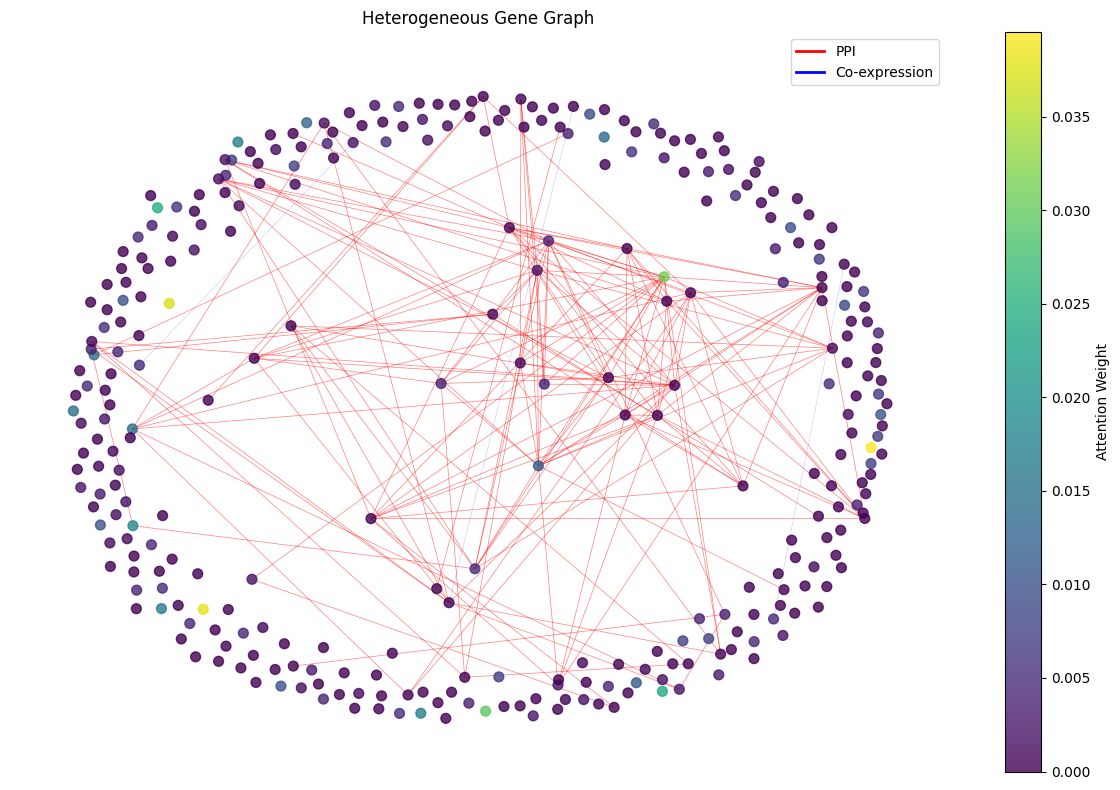

Graph has 315 nodes and 165 edges
PPI edges: 162
Co-expression edges: 3


In [43]:
G = nx.Graph()

# Add nodes
for i, gene in enumerate(gene_names):
    G.add_node(i, name=gene, attention=attention_weights[i].item())

# Add PPI edges
ppi_edges = data['gene', 'ppi', 'gene'].edge_index.numpy()
for i in range(ppi_edges.shape[1]):
    G.add_edge(ppi_edges[0, i], ppi_edges[1, i], edge_type='ppi')

# Add co-expression edges
coexp_edges = data['gene', 'coexpression', 'gene'].edge_index.numpy()
for i in range(coexp_edges.shape[1]):
    G.add_edge(coexp_edges[0, i], coexp_edges[1, i], edge_type='coexpression')

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))

# Node positions using spring layout
pos = nx.spring_layout(G, k=1, iterations=50)

# Node colors based on attention weights
node_colors = [attention_weights[i].item() for i in G.nodes()]

# Draw nodes
nodes = nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                              node_size=50, cmap='viridis', alpha=0.8, ax=ax)

# Draw edges with different colors for different types
ppi_edge_list = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'ppi']
coexp_edge_list = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'coexpression']

nx.draw_networkx_edges(G, pos, edgelist=ppi_edge_list, 
                      edge_color='red', alpha=0.5, width=0.5, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=coexp_edge_list, 
                      edge_color='blue', alpha=0.3, width=0.3, ax=ax)

# Add colorbar
plt.colorbar(nodes, ax=ax, label='Attention Weight')

# Add legend for edges
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='red', lw=2, label='PPI'),
                   Line2D([0], [0], color='blue', lw=2, label='Co-expression')]
ax.legend(handles=legend_elements)

ax.set_title("Heterogeneous Gene Graph")
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
print(f"PPI edges: {len(ppi_edge_list)}")
print(f"Co-expression edges: {len(coexp_edge_list)}")

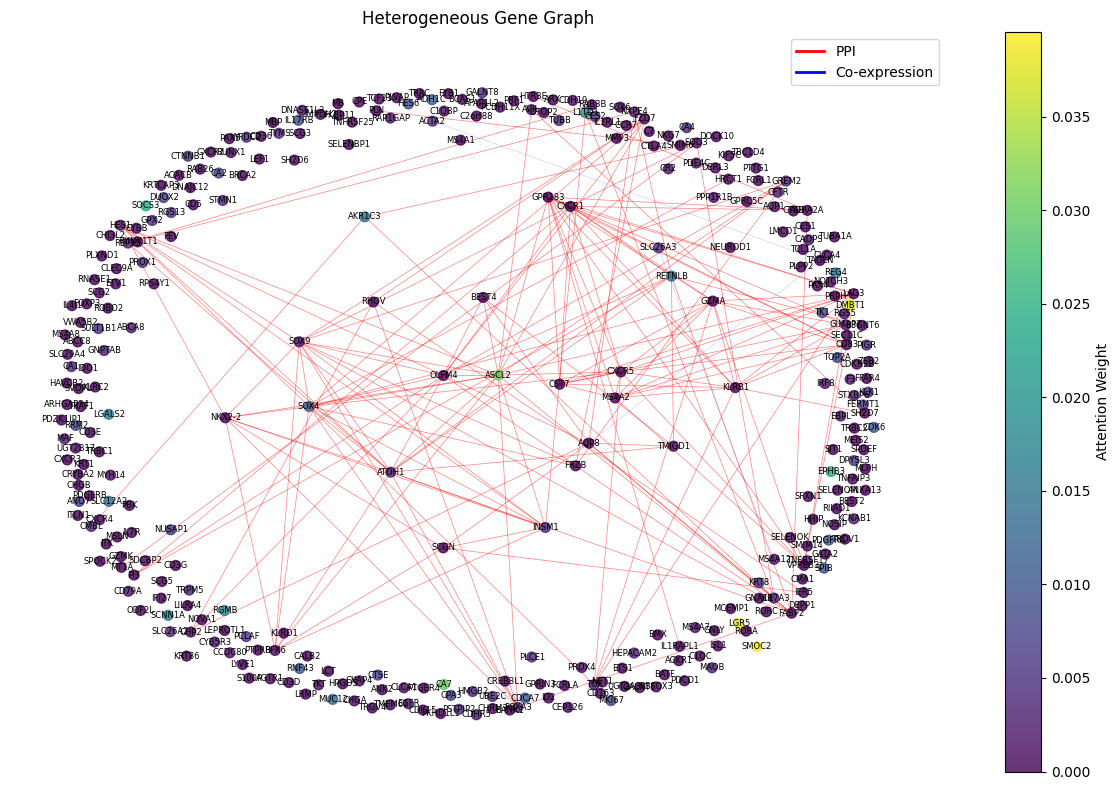

Graph has 315 nodes and 165 edges
PPI edges: 162
Co-expression edges: 3


In [41]:


# Convert to NetworkX for visualization
G = nx.Graph()

# Add nodes
for i, gene in enumerate(gene_names):
   G.add_node(i, name=gene, attention=attention_weights[i].item())

# Add PPI edges
ppi_edges = data['gene', 'ppi', 'gene'].edge_index.numpy()
for i in range(ppi_edges.shape[1]):
   G.add_edge(ppi_edges[0, i], ppi_edges[1, i], edge_type='ppi')

# Add co-expression edges
coexp_edges = data['gene', 'coexpression', 'gene'].edge_index.numpy()
for i in range(coexp_edges.shape[1]):
   G.add_edge(coexp_edges[0, i], coexp_edges[1, i], edge_type='coexpression')

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))

# Node positions using spring layout
pos = nx.spring_layout(G, k=1, iterations=50)

# Node colors based on attention weights
node_colors = [attention_weights[i].item() for i in G.nodes()]

# Draw nodes
nodes = nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                             node_size=50, cmap='viridis', alpha=0.8, ax=ax)

# Draw edges with different colors for different types
ppi_edge_list = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'ppi']
coexp_edge_list = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'coexpression']

nx.draw_networkx_edges(G, pos, edgelist=ppi_edge_list, 
                     edge_color='red', alpha=0.5, width=0.5, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=coexp_edge_list, 
                     edge_color='blue', alpha=0.3, width=0.3, ax=ax)

# Add gene names with small font
labels = {i: gene_names[i] for i in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=6, ax=ax)

# Add colorbar
plt.colorbar(nodes, ax=ax, label='Attention Weight')

# Add legend for edges
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='red', lw=2, label='PPI'),
                  Line2D([0], [0], color='blue', lw=2, label='Co-expression')]
ax.legend(handles=legend_elements)

ax.set_title("Heterogeneous Gene Graph")
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
print(f"PPI edges: {len(ppi_edge_list)}")
print(f"Co-expression edges: {len(coexp_edge_list)}")

## Simplicial complex

In [105]:
num_genes = len(gene_names)
ppi_matrix = np.zeros((num_genes, num_genes))
coexp_matrix = np.zeros((num_genes, num_genes))

In [106]:
ppi_edges = data['gene', 'ppi', 'gene'].edge_index.numpy()
ppi_weights = data['gene', 'ppi', 'gene'].edge_attr.numpy()
for i in range(ppi_edges.shape[1]):
    src, dst = ppi_edges[0, i], ppi_edges[1, i]
    ppi_matrix[src, dst] = ppi_weights[i]
    ppi_matrix[dst, src] = ppi_weights[i]

In [107]:
coexp_edges = data['gene', 'coexpression', 'gene'].edge_index.numpy()
coexp_weights = data['gene', 'coexpression', 'gene'].edge_attr.numpy()
for i in range(coexp_edges.shape[1]):
    src, dst = coexp_edges[0, i], coexp_edges[1, i]
    coexp_matrix[src, dst] = abs(coexp_weights[i])
    coexp_matrix[dst, src] = abs(coexp_weights[i])

In [108]:
ppi_normalized = np.zeros_like(ppi_matrix)
if ppi_matrix.max() > 0:
    ppi_normalized = ppi_matrix / ppi_matrix.max()

coexp_normalized = np.zeros_like(coexp_matrix)
if coexp_matrix.max() > 0:
    coexp_normalized = coexp_matrix / coexp_matrix.max()
    

In [120]:
attention_array = attention_weights.numpy()
attention_normalized = attention_array / attention_array.max()

In [121]:
attention_similarity = np.outer(attention_normalized, attention_normalized)

In [122]:
attention_weighted_ppi = ppi_normalized.copy()
attention_weighted_coexp = coexp_normalized.copy()

for i in range(num_genes):
    for j in range(num_genes):
        if ppi_normalized[i, j] > 0:
            avg_attention = (attention_normalized[i] + attention_normalized[j]) / 2
            attention_weighted_ppi[i, j] *= (1 + avg_attention)  # Boost by attention
        
        if coexp_normalized[i, j] > 0:
            avg_attention = (attention_normalized[i] + attention_normalized[j]) / 2
            attention_weighted_coexp[i, j] *= (1 + avg_attention)

print(f"Attention range: {attention_normalized.min():.3f} to {attention_normalized.max():.3f}")
print(f"Attention similarity range: {attention_similarity.min():.3f} to {attention_similarity.max():.3f}")

Attention range: 0.000 to 1.000
Attention similarity range: 0.000 to 1.000


In [123]:
w_ppi = 0.4
w_coexp = 0.2  
w_attention = 0.4

combined_similarity = (w_ppi * attention_weighted_ppi + 
                      w_coexp * attention_weighted_coexp + 
                      w_attention * attention_similarity)

print(f"Combined similarity range: {combined_similarity.min():.3f} to {combined_similarity.max():.3f}")

Combined similarity range: 0.000 to 0.400


In [124]:
distance_matrix = 1.0 - combined_similarity
np.fill_diagonal(distance_matrix, 0)


In [125]:
connected_distances = distance_matrix[combined_similarity > 0]
threshold = np.percentile(connected_distances, 80)

print(f"Using threshold: {threshold:.3f}")
print(f"Connected edges: {np.sum(distance_matrix <= threshold) - num_genes}")

Using threshold: 1.000
Connected edges: 15804


In [113]:
threshold = np.percentile(connected_distances, 80)
print(f"\nUsing threshold: {threshold:.3f}")


Using threshold: 0.623


In [126]:
rips_complex = gudhi.RipsComplex(distance_matrix=distance_matrix, 
                                max_edge_length=threshold, 
                                sparse=2)

In [127]:
simplex_tree = rips_complex.create_simplex_tree(max_dimension=3)

In [128]:
print(f"Simplex tree has {simplex_tree.num_vertices()} vertices")
print(f"Simplex tree has {simplex_tree.num_simplices()} simplices")

Simplex tree has 315 vertices
Simplex tree has 462 simplices


In [129]:
persistence = simplex_tree.persistence()

<Figure size 3000x3000 with 0 Axes>

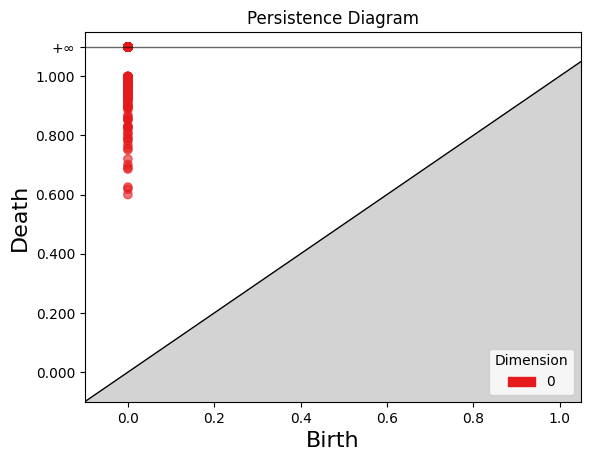

In [130]:
plt.figure(figsize=(10, 10), dpi=300)
gudhi.plot_persistence_diagram(persistence, legend=True)
plt.title("Persistence Diagram")
plt.show()

In [131]:
dim_0 = [(birth, death) for (dim, (birth, death)) in persistence if dim == 0]
dim_1 = [(birth, death) for (dim, (birth, death)) in persistence if dim == 1]
dim_2 = [(birth, death) for (dim, (birth, death)) in persistence if dim == 2]

print(f"H0 (connected components): {len(dim_0)} features")
print(f"H1 (loops): {len(dim_1)} features")
print(f"H2 (voids): {len(dim_2)} features")

H0 (connected components): 315 features
H1 (loops): 0 features
H2 (voids): 0 features


In [42]:
num_genes = len(gene_names)
adjacency_matrix = np.zeros((num_genes, num_genes))

In [43]:
adjacency_matrix

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [44]:
ppi_edges = data['gene', 'ppi', 'gene'].edge_index.numpy()
ppi_weights = data['gene', 'ppi', 'gene'].edge_attr.numpy()
for i in range(ppi_edges.shape[1]):
   src, dst = ppi_edges[0, i], ppi_edges[1, i]
   adjacency_matrix[src, dst] = ppi_weights[i]
   adjacency_matrix[dst, src] = ppi_weights[i]  # Make symmetric

In [45]:
coexp_edges = data['gene', 'coexpression', 'gene'].edge_index.numpy()
coexp_weights = data['gene', 'coexpression', 'gene'].edge_attr.numpy()
for i in range(coexp_edges.shape[1]):
   src, dst = coexp_edges[0, i], coexp_edges[1, i]
   # Add to existing weight (if both PPI and coexpression exist)
   adjacency_matrix[src, dst] += abs(coexp_weights[i])  # Use absolute correlation
   adjacency_matrix[dst, src] += abs(coexp_weights[i])

In [46]:
max_weight = adjacency_matrix.max()
distance_matrix = max_weight - adjacency_matrix
# Set diagonal to 0 (distance from node to itself)
np.fill_diagonal(distance_matrix, 0)

* Distance conversion

In [102]:
max_distance = 400

In [103]:
connected_distances = distance_matrix[(distance_matrix > 0) & (distance_matrix < max_distance)]

In [104]:
print(f"Connected edge distances:")
print(f"Min distance: {connected_distances.min():.3f}")
print(f"Max distance: {connected_distances.max():.3f}")
print(f"Mean distance: {connected_distances.mean():.3f}")
print(f"Number of connected edges: {len(connected_distances)}")

Connected edge distances:


ValueError: zero-size array to reduction operation minimum which has no identity

In [83]:
percentiles = [50, 60, 70, 80, 90, 95]
for p in percentiles:
    val = np.percentile(connected_distances, p)
    edges_at_threshold = np.sum(distance_matrix <= val) - num_genes  # subtract diagonal
    print(f"{p}th percentile: {val:.3f} -> {edges_at_threshold} edges survive")


50th percentile: 441.000 -> 4 edges survive
60th percentile: 441.000 -> 4 edges survive
70th percentile: 441.000 -> 4 edges survive
80th percentile: 441.000 -> 4 edges survive
90th percentile: 441.000 -> 4 edges survive
95th percentile: 441.000 -> 4 edges survive


In [84]:
threshold = np.percentile(connected_distances, 80)
print(f"\nUsing threshold: {threshold:.3f}")


Using threshold: 441.000


In [85]:
surviving_edges = np.sum((distance_matrix <= threshold) & (distance_matrix > 0))
print(f"Edges surviving: {surviving_edges}")

Edges surviving: 2


In [86]:
rips_complex = gudhi.RipsComplex(distance_matrix=distance_matrix, 
                               max_edge_length=threshold, 
                               sparse=2)


In [87]:
simplex_tree = rips_complex.create_simplex_tree(max_dimension=3)

In [88]:
print(f"Simplex tree has {simplex_tree.num_vertices()} vertices")
print(f"Simplex tree has {simplex_tree.num_simplices()} simplices")

Simplex tree has 314 vertices
Simplex tree has 315 simplices


In [89]:
persistence = simplex_tree.persistence()

<Figure size 3000x3000 with 0 Axes>

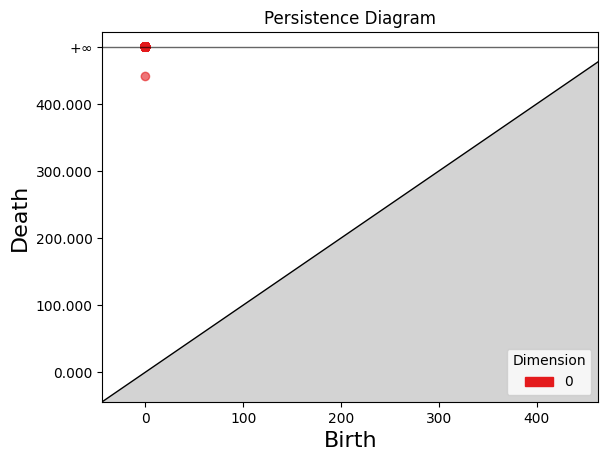

In [90]:
plt.figure(figsize=(10, 10), dpi=300)
gudhi.plot_persistence_diagram(persistence, legend=True)
plt.title("Persistence Diagram")
plt.show()

In [91]:
dim_0 = [(birth, death) for (dim, (birth, death)) in persistence if dim == 0]
dim_1 = [(birth, death) for (dim, (birth, death)) in persistence if dim == 1]
dim_2 = [(birth, death) for (dim, (birth, death)) in persistence if dim == 2]

print(f"H0 (connected components): {len(dim_0)} features")
print(f"H1 (loops): {len(dim_1)} features")
print(f"H2 (voids): {len(dim_2)} features")

H0 (connected components): 314 features
H1 (loops): 0 features
H2 (voids): 0 features


In [92]:
# Check the original edge data
print("Original edge data:")
print(f"PPI edges shape: {data['gene', 'ppi', 'gene'].edge_index.shape}")
print(f"PPI weights range: {data['gene', 'ppi', 'gene'].edge_attr.min().item():.3f} to {data['gene', 'ppi', 'gene'].edge_attr.max().item():.3f}")
print(f"Coexp edges shape: {data['gene', 'coexpression', 'gene'].edge_index.shape}")
print(f"Coexp weights range: {data['gene', 'coexpression', 'gene'].edge_attr.min().item():.3f} to {data['gene', 'coexpression', 'gene'].edge_attr.max().item():.3f}")

# Check adjacency matrix
print(f"\nAdjacency matrix:")
print(f"Non-zero entries: {np.count_nonzero(adjacency_matrix)}")
print(f"Adjacency range: {adjacency_matrix.min():.3f} to {adjacency_matrix.max():.3f}")
print(f"Matrix shape: {adjacency_matrix.shape}")

# Check distance matrix
print(f"\nDistance matrix:")
print(f"Distance range: {distance_matrix.min():.3f} to {distance_matrix.max():.3f}")
print(f"Non-zero distances: {np.count_nonzero(distance_matrix)}")
print(f"Threshold used: {threshold:.3f}")

# Check how many edges survive the threshold
surviving_edges = np.sum(distance_matrix <= threshold) - len(gene_names)  # subtract diagonal
print(f"Edges surviving threshold: {surviving_edges}")

Original edge data:
PPI edges shape: torch.Size([2, 324])
PPI weights range: 0.000 to 1341.000
Coexp edges shape: torch.Size([2, 3])
Coexp weights range: 0.723 to 0.801

Adjacency matrix:
Non-zero entries: 30
Adjacency range: 0.000 to 1341.000
Matrix shape: (315, 315)

Distance matrix:
Distance range: 0.000 to 1341.000
Non-zero distances: 98908
Threshold used: 441.000
Edges surviving threshold: 4
